In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

#Basic Pendlulum

Strin's length $L$

In [ ]:
# defining r radius of the sphere:
r = 0.03 # m
# measured L length for
L_i_cm = np.array([95.5, 95.5, 95.5, 95.5]) # cm
L_i = L_i_cm/100 # m
L = L_i + r
print(L)
L_av = sum(L)/len(L)
print("L_av = ", L_av, "m")

[0.985 0.985 0.985 0.985]
L_av =  0.985 m


Periot $τ$ for basic pendulum

In [ ]:
simple_pendulum_10_periods = np.array([19.75, 19.54, 19.56, 19.53,19.55,19.30,19.27,19.70,19.57,19.71]) # s
simple_pendulum_1_periods = simple_pendulum_10_periods/10
period_average_simple = sum(simple_pendulum_1_periods)/len(simple_pendulum_1_periods)
print("average period = ", period_average_simple, "s")

average period =  1.9547999999999999 s


Using
#$g=4\pi^2\frac{L_{av}}{\tau_{av}^2}$

In [ ]:
g = lambda L,tau: 4*(np.pi**2)*(L/tau**2)
g_simple = g(L_av, period_average_simple)
print("g = ", g_simple, "m/s^2")

g =  10.176332919219938 m/s^2


#Physical Pendulum


In [ ]:
h_i = np.array([-24.5, -17.5, -11.8 ,-6, 6, 11.8, 17.5, 24.5])
ten_periods_physical = np.array([[11.94,11.41], [10.82,10.90], [10.91, 10.32], [12.17,11.53], [12.17,11.53], [10.91, 10.32], [10.82,10.90], [11.94,11.41]])

In [ ]:
ten_periods_av_physical = np.array([sum(i)/len(i) for i in ten_periods_physical])
print(ten_periods_av_physical)
period_average_physical = ten_periods_av_physical/10
print(period_average_physical)

[11.675 10.86  10.615 11.85  11.85  10.615 10.86  11.675]
[1.1675 1.086  1.0615 1.185  1.185  1.0615 1.086  1.1675]


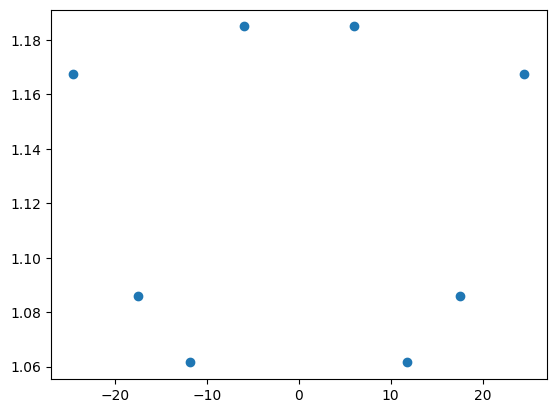

In [ ]:

plt.scatter(h_i, period_average_physical)
plt.show()

In [ ]:
h_linespace = np.linspace(-25,25,1000).reshape(-1,1)
h_space_1, h_space_2 = h_linespace[:len(h_linespace)//2], h_linespace[len(h_linespace)//2:]

print(h_space_1, h_space_2)
print(len(h_space_1), len(h_space_2))

[[-25.        ]
 [-24.94994995]
 [-24.8998999 ]
 [-24.84984985]
 [-24.7997998 ]
 [-24.74974975]
 [-24.6996997 ]
 [-24.64964965]
 [-24.5995996 ]
 [-24.54954955]
 [-24.4994995 ]
 [-24.44944945]
 [-24.3993994 ]
 [-24.34934935]
 [-24.2992993 ]
 [-24.24924925]
 [-24.1991992 ]
 [-24.14914915]
 [-24.0990991 ]
 [-24.04904905]
 [-23.998999  ]
 [-23.94894895]
 [-23.8988989 ]
 [-23.84884885]
 [-23.7987988 ]
 [-23.74874875]
 [-23.6986987 ]
 [-23.64864865]
 [-23.5985986 ]
 [-23.54854855]
 [-23.4984985 ]
 [-23.44844845]
 [-23.3983984 ]
 [-23.34834835]
 [-23.2982983 ]
 [-23.24824825]
 [-23.1981982 ]
 [-23.14814815]
 [-23.0980981 ]
 [-23.04804805]
 [-22.997998  ]
 [-22.94794795]
 [-22.8978979 ]
 [-22.84784785]
 [-22.7977978 ]
 [-22.74774775]
 [-22.6976977 ]
 [-22.64764765]
 [-22.5975976 ]
 [-22.54754755]
 [-22.4974975 ]
 [-22.44744745]
 [-22.3973974 ]
 [-22.34734735]
 [-22.2972973 ]
 [-22.24724725]
 [-22.1971972 ]
 [-22.14714715]
 [-22.0970971 ]
 [-22.04704705]
 [-21.996997  ]
 [-21.94694695]
 [-21.89

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features_1 = poly.fit_transform(h_i[:len(h_i)//2].reshape(-1,1))
poly_features_2 = poly.fit_transform(h_i[len(h_i)//2:].reshape(-1,1))

print(poly_features_1)
poly_reg_model_1 = LinearRegression()

poly_reg_model_2 = LinearRegression()

poly_reg_model_1.fit(poly_features_1, period_average_physical[:len(h_i)//2])
poly_reg_model_2.fit(poly_features_2, period_average_physical[len(h_i)//2:])

poly_features_to_pred_1 = poly.fit_transform(h_space_1)
y_predicted_1 = poly_reg_model_1.predict(poly_features_to_pred_1)

poly_features_to_pred_2 = poly.fit_transform(h_space_2)
y_predicted_2 = poly_reg_model_2.predict(poly_features_to_pred_2)

[[-24.5  600.25]
 [-17.5  306.25]
 [-11.8  139.24]
 [ -6.    36.  ]]


τ

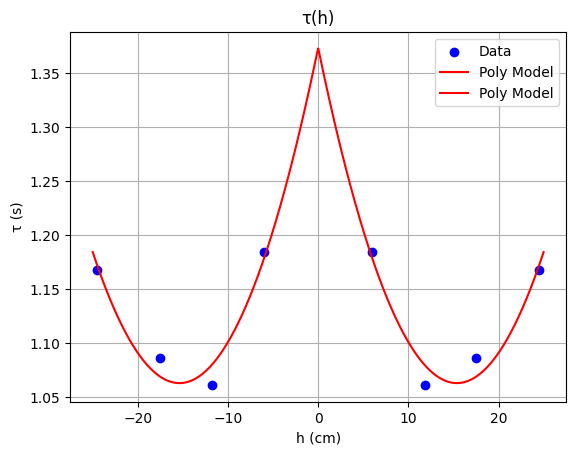

In [ ]:
plt.title("τ(h)")
plt.scatter(h_i, period_average_physical, c="blue", label="Data")
plt.plot(h_space_1, y_predicted_1, c="red", label="Poly Model")
plt.plot(h_space_2, y_predicted_2, c="red", label="Poly Model")
plt.xlabel("h (cm)")
plt.ylabel("τ (s)")
plt.legend()
plt.grid(True)
plt.show()

<ipython-input-174-b2a5bebbf0ce>:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(float(x_val)-2.9, 1.02, str(round(float(x_val), 2)), ha='center') # Annotation on x-axis


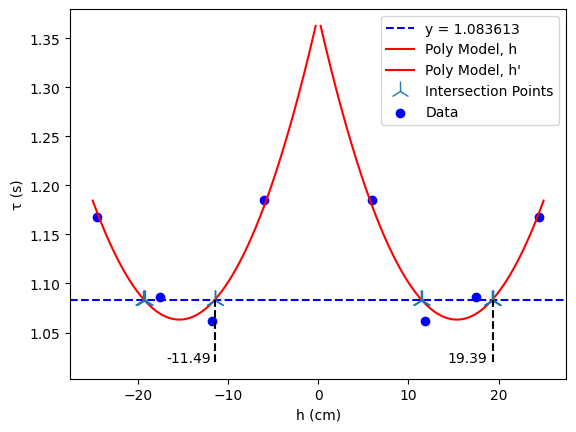

In [ ]:
y_constant = 1.083613
intersection_indices = np.where(np.isclose(list(y_predicted_1)+list(y_predicted_2), y_constant, atol=1e-3))
intersection_x_values = h_linespace[intersection_indices]
plt.axhline(y=y_constant, color='blue', linestyle='--', label=f'y = {y_constant}')

# Mark the intersection points on the graph
plt.plot(h_space_1[:-5], y_predicted_1[:-5], c="red", label="Poly Model, h")
plt.plot(h_space_2[5:], y_predicted_2[5:], c="red", label="Poly Model, h'")
plt.plot(intersection_x_values, [y_constant] * len(intersection_x_values), '2', label='Intersection Points',ms=15, linewidth=6)

# Add vertical lines and annotate x-axis
intersection_x_values = [intersection_x_values[-1]]+[intersection_x_values[len(intersection_x_values)//3]]
for x_val in intersection_x_values:
    plt.plot([x_val, x_val], [1.02, y_constant], 'k--')  # Vertical line
    plt.text(float(x_val)-2.9, 1.02, str(round(float(x_val), 2)), ha='center') # Annotation on x-axis

plt.scatter(h_i, period_average_physical, c="blue", label="Data")
plt.xlabel("h (cm)")
plt.ylabel("τ (s)")
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
L_physical_to_simple = [abs(i) for i in intersection_x_values]
L_physical_to_simple = sum(L_physical_to_simple)
print(L_physical_to_simple)

[30.88088088]


In [ ]:
g_physical = g(L_physical_to_simple, y_constant)
print("g = ",g_physical, "cm/s^2")

print("g = ",g_physical/100, "m/s^2")

g =  [1038.24776214] cm/s^2
g =  [10.38247762] m/s^2
